# SemanticKITTI LiDAR Segmentation with MMDetection3D

This tutorial evaluates an MMDetection3D LiDAR segmentation model on SemanticKITTI using PerceptionMetrics.



## Data, Repository, and Checkpoint Links

Resources used by this tutorial:

- SemanticKITTI dataset page: <http://semantic-kitti.org/dataset.html#download>
- KITTI Odometry Velodyne point clouds: <https://www.cvlibs.net/download.php?file=data_odometry_velodyne.zip>
- KITTI Odometry calibration data: <https://www.cvlibs.net/download.php?file=data_odometry_calib.zip>
- SemanticKITTI labels: <https://semantic-kitti.org/assets/data_odometry_labels.zip>
- MMDetection3D repository: <https://github.com/open-mmlab/mmdetection3d>
- MMDetection3D MinkUNet model zoo page: <https://github.com/open-mmlab/mmdetection3d/tree/main/configs/minkunet>
- MinkUNet34 W32 SpConv checkpoint used here: <https://download.openmmlab.com/mmdetection3d/v1.1.0_models/minkunet/minkunet34_w32_spconv_8xb2-laser-polar-mix-3x_semantickitti_20230512_233817-72b200d8.pth>

For this notebook, keep tutorial artifacts under the notebook-local `local/` directory:

- Raw SemanticKITTI data and `semantic-kitti.yaml`: `local/data/SemanticKITTI`
- MMDetection3D checkpoint: `local/models/minkunet34_w32_spconv_semantickitti.pth`
- MMDetection3D config copy: `local/models/mmdet3d_configs/minkunet/minkunet34_w32_spconv_8xb2-laser-polar-mix-3x_semantickitti.py`
- PerceptionMetrics MMDet3D model config: `local/data/mmdet3d_lidar_segmentation_model_cfg.json`

Download the checkpoint into `local/models`:

```bash
mkdir -p local/models
wget -O local/models/minkunet34_w32_spconv_semantickitti.pth \
  https://download.openmmlab.com/mmdetection3d/v1.1.0_models/minkunet/minkunet34_w32_spconv_8xb2-laser-polar-mix-3x_semantickitti_20230512_233817-72b200d8.pth
```

## MMDetection3D Environment

The MMDetection3D dependency stack is version-sensitive. The following installation sequence has worked for this tutorial setup using PyTorch 2.0, CUDA 11.7 wheels, MMCV 2.1.0, and the SpConv-based MinkUNet checkpoint:

```bash
pip install torch==2.0.1 torchvision==0.15.2

pip install openmim
mim install mmengine

pip install mmcv==2.1.0 -f https://download.openmmlab.com/mmcv/dist/cu117/torch2.0/index.html

mim install 'mmdet>=3.0.0'
mim install "mmdet3d>=1.1.0"

pip install spconv-cu117
```

This uses the CUDA 11.7 / PyTorch 2.0 MMCV wheel index. If your CUDA or PyTorch version is different, use the matching MMCV wheel from OpenMMLab. Models using TorchSparse need the additional TorchSparse installation step for the active CUDA/PyTorch environment.


There are two label spaces to keep straight:

- SemanticKITTI raw labels use IDs such as `10` for car, `40` for road, and `252` for moving-car.
- PerceptionMetrics loads the raw labels directly. Evaluation translates those labels in memory.
- MMDetection3D SemanticKITTI models predict only the 19 valid classes, indexed `0..18`, with no `unlabeled` output channel.

The first step builds the dataset and keeps the original SemanticKITTI labels on disk.


In [1]:
from perceptionmetrics.datasets.semantickitti import SemanticKITTILiDARSegmentationDataset

config_fname = "local/data/SemanticKITTI/semantic-kitti.yaml"

dataset = SemanticKITTILiDARSegmentationDataset(
    dataset_dir="local/data/SemanticKITTI",
    config_fname=config_fname,
    split="val",
)

print("Dataset labels remain in the raw SemanticKITTI ontology.")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Building dataset from SemanticKITTI directory: /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/PerceptionMetrics/examples/local/data/SemanticKITTI
Samples retrieved: 4071 / 4071
Dataset labels remain in the raw SemanticKITTI ontology.


## Build the MMDetection3D Output Ontology

The dataset already owns the raw SemanticKITTI ontology through `dataset.ontology`. The only extra ontology needed here is the MMDetection3D model ontology, because the model outputs `0..18`, where `0` is `car`.

This cell builds that model ontology directly from `semantic-kitti.yaml` and writes a translation file that maps raw SemanticKITTI class names directly to the MMDetection3D model ontology. 

In [2]:
from collections import OrderedDict

import perceptionmetrics.utils.io as uio

semkitti_cfg = uio.read_yaml(config_fname)
labels = semkitti_cfg["labels"]
color_map = semkitti_cfg["color_map"]
learning_map = semkitti_cfg["learning_map"]
learning_map_inv = semkitti_cfg["learning_map_inv"]

mmdet3d_ontology = OrderedDict()
for train_id in sorted(learning_map_inv):
    train_id = int(train_id)
    if train_id == 0:
        continue

    raw_id = int(learning_map_inv[train_id])
    class_name = labels[raw_id]
    bgr = color_map[raw_id]
    mmdet3d_ontology[class_name] = {
        "idx": train_id - 1,
        "rgb": tuple(reversed(bgr)),
    }

raw_to_mmdet3d_translation = OrderedDict()
ignored_raw_classes = []
for raw_id in sorted(labels):
    raw_id = int(raw_id)
    raw_class_name = labels[raw_id]
    train_id = int(learning_map[raw_id])

    if train_id == 0:
        ignored_raw_classes.append(raw_class_name)
        continue

    train_raw_id = int(learning_map_inv[train_id])
    raw_to_mmdet3d_translation[raw_class_name] = labels[train_raw_id]

uio.write_json(
    "local/data/semantickitti_mmdet3d_ontology.json",
    mmdet3d_ontology,
)

uio.write_json(
    "local/data/semantickitti_raw_to_mmdet3d_translation.json",
    raw_to_mmdet3d_translation,
)

print("Ignored raw classes:", ignored_raw_classes)
print("Raw-to-model translated classes:", len(raw_to_mmdet3d_translation))


Ignored raw classes: ['unlabeled', 'outlier', 'other-structure', 'other-object']
Raw-to-model translated classes: 30


## Build the PerceptionMetrics Model Config

PerceptionMetrics uses a small JSON config to select the model adapter, point feature count, evaluation batch settings, and GT classes ignored during metrics. This helper writes that config into `local/data` so the tutorial can be rebuilt from the notebook cells.


In [3]:
def build_mmdet3d_model_cfg(
    out_fname="local/data/mmdet3d_lidar_segmentation_model_cfg.json",
    n_feats=4,
    batch_size=1,
    num_workers=1,
    ignored_classes=None,
):
    ignored_classes = ignored_raw_classes if ignored_classes is None else ignored_classes
    model_cfg = {
        "model_format": "mmdet3d",
        "n_feats": n_feats,
        "batch_size": batch_size,
        "num_workers": num_workers,
        "ignored_classes": ignored_classes,
    }
    uio.write_json(out_fname, model_cfg)
    return out_fname, model_cfg


model_cfg_fname, model_cfg = build_mmdet3d_model_cfg()
model_cfg


{'model_format': 'mmdet3d',
 'n_feats': 4,
 'batch_size': 1,
 'num_workers': 1,
 'ignored_classes': ['unlabeled',
  'outlier',
  'other-structure',
  'other-object']}

## Load the MMDetection3D Model

Load the configured MMDetection3D model and checkpoint. The selected MinkUNet checkpoint was trained with the MMDetection3D SemanticKITTI convention: valid classes only, indexed `0..18`.


In [4]:
from mmdet3d.apis import init_model


mmdet3d_model = init_model(
    config="local/models/mmdet3d_configs/minkunet/minkunet34_w32_spconv_8xb2-laser-polar-mix-3x_semantickitti.py",
    checkpoint="local/models/minkunet34_w32_spconv_semantickitti.pth",
    device="cuda:0",
)


Loads checkpoint by local backend from path: local/models/minkunet34_w32_spconv_semantickitti.pth


## Wrap the Model for PerceptionMetrics

The PerceptionMetrics model wrapper needs the ontology of the model outputs. Here we pass the MMDetection3D ontology created above, not the raw SemanticKITTI ontology and not the `0..19` train-id ontology.


In [5]:
from perceptionmetrics.models import TorchLiDARSegmentationModel
import numpy as np
pm_model = TorchLiDARSegmentationModel(
    model=mmdet3d_model,
    model_cfg=model_cfg_fname,
    ontology_fname="local/data/semantickitti_mmdet3d_ontology.json",
)


Torch detection not available
Tensorflow not available
Open3D-ML3D not available


/home/tejass/miniconda3/envs/pm/lib/python3.11/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/tejass/miniconda3/envs/pm/lib/python3.11/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any fe

## Inspect One Sample

Run inference on one validation sample and print the prediction and label ranges. Before evaluation translation, predictions are in the MMDetection3D model space and labels are still in the raw SemanticKITTI dataset space.


In [6]:
import torch

# Take first validation sample from your PM SemanticKITTI dataset
row = dataset.dataset.iloc[0]
sample_name = dataset.dataset.index[0]

sample = pm_model._get_sample(
    points_fname=row["points"],
    model_cfg=pm_model.model_cfg,
    label_fname=row["label"],
    name=sample_name,
    idx=0,
    has_intensity=dataset.has_intensity,
)

pred, label, name = pm_model.inference(
    sample,
    pm_model.model,
    pm_model.model_cfg,
)

print("name:", name)
print("pred shape:", pred.shape)
print("label shape:", label.shape)

print("pred unique:", torch.unique(pred)[:80])
print("label unique:", torch.unique(label)[:80])

print("pred min/max:", pred.min().item(), pred.max().item())
print("label min/max:", label.min().item(), label.max().item())


name: ['08-000000']
pred shape: torch.Size([123389])
label shape: torch.Size([123389])
pred unique: tensor([ 0,  1,  2,  4,  5,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
       device='cuda:0')
label unique: tensor([  0,   1,  10,  11,  30,  40,  44,  48,  50,  51,  52,  70,  71,  72,
         80,  81,  99, 252, 254], device='cuda:0')
pred min/max: 0 18
label min/max: 0 254


## Check the Model Ontology

Print the MMDetection3D ontology to confirm that class IDs run from `0` to `18` and do not include `unlabeled`.


In [7]:
for name, data in mmdet3d_ontology.items():
    print(data["idx"], name, data["rgb"])


0 car (100, 150, 245)
1 bicycle (100, 230, 245)
2 motorcycle (30, 60, 150)
3 truck (80, 30, 180)
4 other-vehicle (0, 0, 255)
5 person (255, 30, 30)
6 bicyclist (255, 40, 200)
7 motorcyclist (150, 30, 90)
8 road (255, 0, 255)
9 parking (255, 150, 255)
10 sidewalk (75, 0, 75)
11 other-ground (175, 0, 75)
12 building (255, 200, 0)
13 fence (255, 120, 50)
14 vegetation (0, 175, 0)
15 trunk (135, 60, 0)
16 terrain (150, 240, 80)
17 pole (255, 240, 150)
18 traffic-sign (255, 0, 0)


## Visualize Prediction and Ground Truth

For visualization, unlabeled GT points are masked out and the remaining GT labels are shifted from PerceptionMetrics train IDs `1..19` into MMDetection3D IDs `0..18`. This makes the prediction and GT colors use the same ontology.


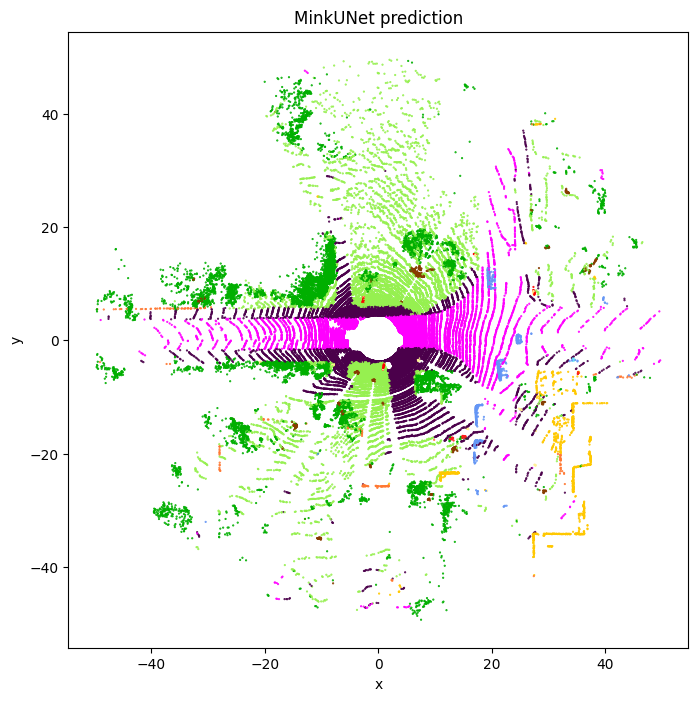

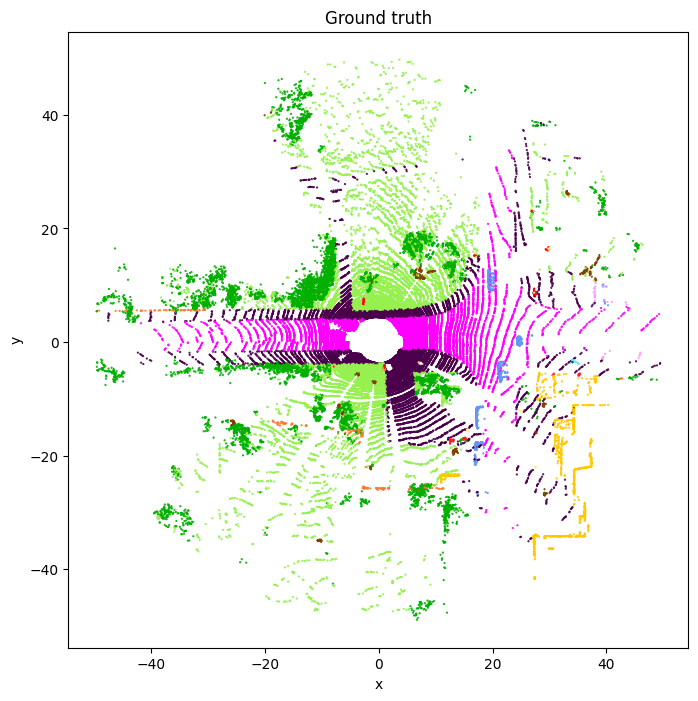

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def build_color_lut(ontology):
    max_idx = max(class_data["idx"] for class_data in ontology.values())
    color_lut = np.zeros((max_idx + 1, 3), dtype=np.float32)

    for class_name, class_data in ontology.items():
        idx = class_data["idx"]
        rgb = np.array(class_data["rgb"], dtype=np.float32) / 255.0
        color_lut[idx] = rgb

    return color_lut


def build_translation_lut(old_ontology, new_ontology, translation):
    max_idx = max(class_data["idx"] for class_data in old_ontology.values())
    lut = np.zeros(max_idx + 1, dtype=np.int64)
    for old_name, new_name in translation.items():
        lut[old_ontology[old_name]["idx"]] = new_ontology[new_name]["idx"]
    return lut


def plot_bev_with_lut(points, labels, color_lut, title, max_points=60000):
    labels = np.asarray(labels, dtype=np.int64)
    labels = np.clip(labels, 0, len(color_lut) - 1)
    colors = color_lut[labels]

    if len(points) > max_points:
        idx = np.random.choice(len(points), max_points, replace=False)
        points = points[idx]
        colors = colors[idx]

    plt.figure(figsize=(8, 8))
    plt.scatter(points[:, 0], points[:, 1], c=colors, s=0.3)
    plt.axis("equal")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


row = dataset.dataset.iloc[0]
points = np.fromfile(row["points"], dtype=np.float32).reshape(-1, 4)

pred_np = pred.detach().cpu().numpy()
label_np = label.detach().cpu().numpy()
ignored_raw_indices = [dataset.ontology[name]["idx"] for name in ignored_raw_classes]
valid_mask = ~np.isin(label_np, ignored_raw_indices)

raw_to_mmdet3d_lut = build_translation_lut(
    dataset.ontology,
    mmdet3d_ontology,
    raw_to_mmdet3d_translation,
)
label_mmdet3d_np = raw_to_mmdet3d_lut[label_np[valid_mask]]

color_lut = build_color_lut(mmdet3d_ontology)

plot_bev_with_lut(points[valid_mask], pred_np[valid_mask], color_lut, "MinkUNet prediction")
plot_bev_with_lut(points[valid_mask], label_mmdet3d_np, color_lut, "Ground truth")


## Evaluate

During evaluation, PerceptionMetrics masks ignored dataset labels such as `unlabeled`, converts GT labels into the MMDetection3D model label space using the translation LUT, and then updates the segmentation metrics.


In [9]:
results = pm_model.eval(
    dataset,
    split="val",
    ontology_translation="local/data/semantickitti_raw_to_mmdet3d_translation.json",
    translation_direction="dataset_to_model",
)
display(results)


100%|██████████| 4071/4071 [09:46<00:00,  6.94it/s]


,car,bicycle,motorcycle,truck,other-vehicle,person,bicyclist,motorcyclist,road,parking,...,other-ground,building,fence,vegetation,trunk,terrain,pole,traffic-sign,macro,micro
tp,3.062294e+07,1.666370e+05,3.221650e+05,4.948680e+05,1.607450e+06,4.229280e+05,2.967170e+05,2.352000e+03,8.555676e+07,3.502738e+06,...,6.310000e+02,5.510514e+07,9.765059e+06,1.398056e+08,4.204733e+06,5.002800e+07,1.322542e+06,2.210710e+05,NaN,NaN
fp,7.310320e+05,5.959400e+04,5.164600e+04,6.932900e+04,4.641700e+04,5.018800e+04,2.798400e+04,3.180000e+03,2.195935e+06,2.883830e+05,...,3.141100e+04,3.346526e+06,2.069072e+06,1.510013e+07,5.714340e+05,6.711345e+06,3.239320e+05,4.332100e+04,NaN,NaN
fn,2.331700e+05,8.115900e+04,2.370300e+04,1.383600e+04,6.148180e+05,5.401800e+04,1.014300e+04,2.038500e+04,2.406863e+06,2.444954e+06,...,4.570190e+05,1.773756e+06,2.877598e+06,6.131381e+06,1.298546e+06,1.408326e+07,3.438850e+05,1.603710e+05,NaN,NaN
tn,4.451706e+08,4.764503e+08,4.763602e+08,4.761797e+08,4.744890e+08,4.762306e+08,4.764229e+08,4.767318e+08,3.865982e+08,4.705216e+08,...,4.762687e+08,4.165323e+08,4.620460e+08,3.157206e+08,4.706830e+08,4.059351e+08,4.747674e+08,4.763330e+08,NaN,NaN
precision,9.766845e-01,7.365790e-01,8.618393e-01,8.771192e-01,9.719343e-01,8.939203e-01,9.138161e-01,4.251627e-01,9.749759e-01,9.239320e-01,...,1.969290e-02,9.427471e-01,8.251606e-01,9.025205e-01,8.803572e-01,8.817162e-01,8.032571e-01,8.361486e-01,0.818298,0.920561
recall,9.924433e-01,6.724766e-01,9.314681e-01,9.728015e-01,7.233376e-01,8.867419e-01,9.669458e-01,1.034437e-01,9.726380e-01,5.889239e-01,...,1.378783e-03,9.688152e-01,7.723898e-01,9.579861e-01,7.640414e-01,7.803309e-01,7.936393e-01,5.795665e-01,0.755211,0.920561
accuracy,9.979776e-01,9.997048e-01,9.998420e-01,9.998256e-01,9.986131e-01,9.997814e-01,9.999200e-01,9.999506e-01,9.903456e-01,9.942668e-01,...,9.989755e-01,9.892602e-01,9.896244e-01,9.554669e-01,9.960777e-01,9.563833e-01,9.985993e-01,9.995728e-01,0.991638,0.991638
f1_score,9.845009e-01,7.030697e-01,8.953019e-01,9.224859e-01,8.294087e-01,8.903166e-01,9.396305e-01,1.664014e-01,9.738055e-01,7.193357e-01,...,2.577130e-03,9.556034e-01,7.979036e-01,9.294266e-01,8.180855e-01,8.279313e-01,7.984193e-01,6.846063e-01,0.776241,0.920561
iou,9.694749e-01,5.421029e-01,8.104494e-01,8.561241e-01,7.085382e-01,8.023159e-01,8.861350e-01,9.075124e-02,9.489483e-01,5.616895e-01,...,1.290228e-03,9.149814e-01,6.637601e-01,8.681577e-01,6.921698e-01,7.063846e-01,6.644741e-01,5.204573e-01,0.686456,0.852813
dice_score,9.845009e-01,7.030697e-01,8.953019e-01,9.224859e-01,8.294087e-01,8.903166e-01,9.396305e-01,1.664014e-01,9.738055e-01,7.193357e-01,...,2.577130e-03,9.556034e-01,7.979036e-01,9.294266e-01,8.180855e-01,8.279313e-01,7.984193e-01,6.846063e-01,0.776241,0.920561
